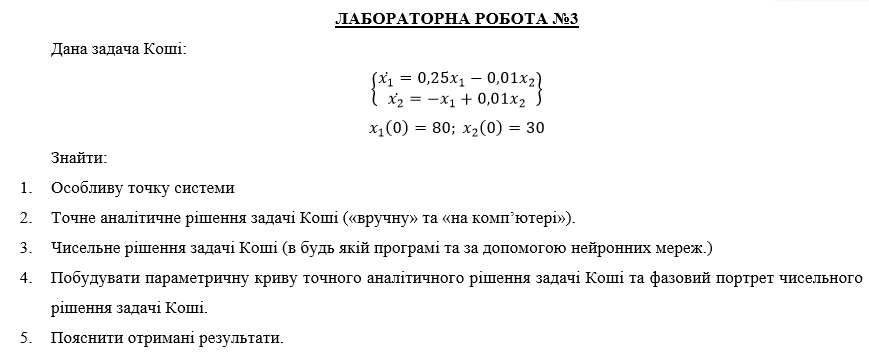

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import sympy as sp

# Визначення власних значень
A = sp.Matrix([[0.25,-0.01],[-1,0.01]])
eigs = A.eigenvects()
print('Власні числа матриці А:', eigs[0][0], eigs[1][0], sep = '\n')

Власні числа матриці А:
0.286204993518133
-0.0262049935181331


In [2]:
# Пошук точного аналітичного рішення

t = sp.symbols('t')
x1_sym, x2_sym = sp.symbols('x1 x2', cls=sp.Function)

# Рівняння
eq1 = sp.Eq(x1_sym(t).diff(t), 0.25*x1_sym(t) - 0.01*x2_sym(t))
eq2 = sp.Eq(x2_sym(t).diff(t), -1*x1_sym(t) + 0.01*x2_sym(t))

# Розв'язання задачі Коші
sol_exact = sp.dsolve([eq1, eq2], ics={x1_sym(0): 80, x2_sym(0): 30})

print("Точне аналітичне рішення")
print(f"x1(t) = {sol_exact[0].rhs.evalf(3)}")
print(f"x2(t) = {sol_exact[1].rhs.evalf(3)}")

Точне аналітичне рішення
x1(t) = 69.8*exp(0.286204993518133*t) + 10.2*exp(-0.0262049935181331*t)
x2(t) = -253.0*exp(0.286204993518133*t) + 283.0*exp(-0.0262049935181331*t)


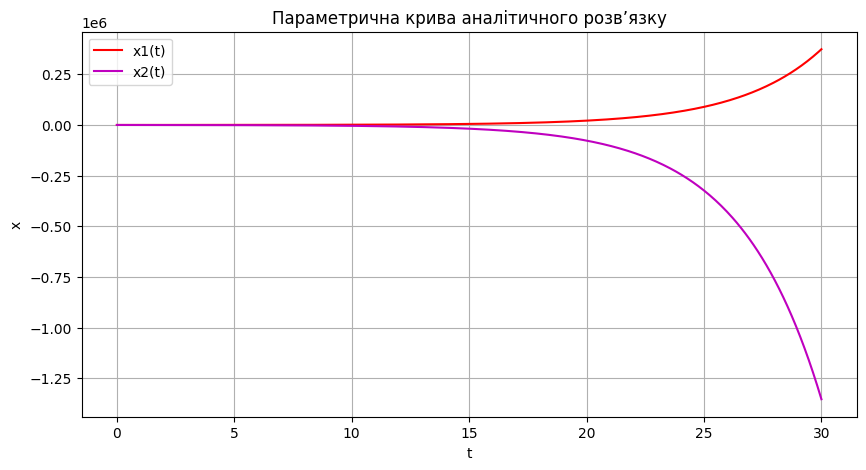

In [3]:
t_eval = np.linspace(0, 30, 500)

x1_exact = sol_exact[0].rhs
x2_exact = sol_exact[1].rhs

f1 = sp.lambdify(t, x1_exact, 'numpy')
f2 = sp.lambdify(t, x2_exact, 'numpy')

X1_exact = f1(t_eval)
X2_exact = f2(t_eval)

plt.figure(figsize=(10,5))

plt.plot(t_eval, X1_exact, 'r', label='x1(t)')
plt.plot(t_eval, X2_exact, 'm', label='x2(t)')

plt.xlabel("t")
plt.ylabel("x")
plt.title("Параметрична крива аналітичного розв’язку")
plt.grid()
plt.legend()
plt.show()

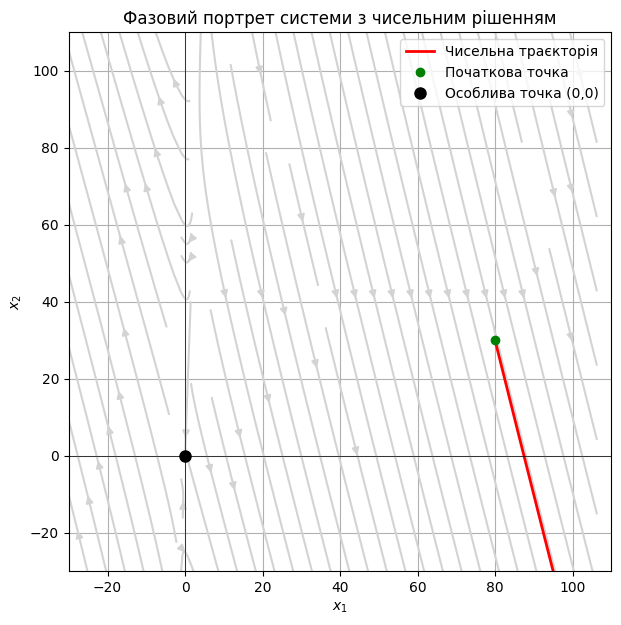

In [4]:
# Матриця системи
A = np.array([[0.25, -0.01], [-1., 0.01]])

# Векторна функція
def f(t, x):
    return A.dot(x)

# Чисельне рішення задачі Коші
x0 = [80, 30]
t_span = (0, 10)
t_eval = np.linspace(*t_span, 300)
sol = solve_ivp(f, t_span, x0, t_eval=t_eval)

# Сітка для напрямного поля
xmin, xmax = -30, 110
ymin, ymax = -30, 110
nx, ny = 25, 25
x = np.linspace(xmin, xmax, nx)
y = np.linspace(ymin, ymax, ny)
X, Y = np.meshgrid(x, y)
U = 0.25 * X - 0.01 * Y      # ẋ1
V = -1 * X + 0.01 * Y        # ẋ2

# Побудова фазового портрету
plt.figure(figsize=(7,7))

# Напрямне поле
plt.streamplot(X, Y, U, V, density=1.0, color='lightgray')

# Траєкторія чисельного розв’язку
plt.plot(sol.y[0], sol.y[1], 'r', linewidth=2, label='Чисельна траєкторія')
plt.plot(sol.y[0,0], sol.y[1,0], 'go', label='Початкова точка')

# Особлива точка
plt.plot(0, 0, 'ko', markersize=8, label='Особлива точка (0,0)')

# Налаштування осей та сітки
plt.axhline(0, linewidth=0.5, color='black')
plt.axvline(0, linewidth=0.5, color='black')
plt.xlim(xmin, xmax)
plt.ylim(ymin, ymax)
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.title('Фазовий портрет системи з чисельним рішенням')

# Легенда в верхньому правому куті
plt.legend(loc='upper right')
plt.grid(True)
plt.show()